In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [70]:
game_folder = "data/game_data.csv"
time_folder = "data/time_data.csv"
tagged_folder = "data/game_data_with_tags.csv"

game_data = pd.read_csv(game_folder)
time_data = pd.read_csv(time_folder)
tagged_data = pd.read_csv(tagged_folder)

In [71]:
time_data["playtime"] = (time_data["playtime"]/60).astype(int)

In [72]:
tagged_data.sample(10)

,game_id,game_steam_id,game_name,tag_0,tag_1,tag_2,tag_3,tag_4,rating
8617,10297,985830,SUCCUBUS,Sexual Content,Nudity,Mature,Gore,Female Protagonist,77.0
9884,12412,348870,Night Mysteries: The Amphora Prisoner,Adventure,Puzzle,3D,First-Person,Idler,60.0
901,968,500,Left 4 Dead,Zombies,Co-op,Multiplayer,FPS,Action,96.0
11486,17587,404680,Hob,Adventure,Action,Singleplayer,Indie,Puzzle,88.0
589,625,851520,Trivia Vault: TV Trivia,Trivia,Casual,Simulation,Strategy,Action,60.0
3698,3851,1000010,Crown Trick,Roguelike,Turn-Based Combat,RPG,Perma Death,Dungeon Crawler,85.0
2089,2171,342620,It came from space and ate our brains,Top-Down Shooter,Twin Stick Shooter,Shooter,Survival,Arcade,79.0
935,1003,6120,Shank,Action,Beat 'em up,Indie,2D,Side Scroller,90.0
2642,2733,428900,"Linea, the Game",Indie,Casual,Minimalist,Difficult,Action,86.0
1905,1984,323060,Tharsis,Board Game,Space,Strategy,Survival,Singleplayer,71.0


In [73]:
time_data.sample(10)

,user_id,game_id,playtime
208670,312,976,14
1384929,4732,5360,533
404917,587,7325,1
1358805,4543,5652,0
1640041,6202,10243,1
1488721,5369,4877,19
380678,582,6409,2
908698,1645,1331,2
905654,1622,727,0
1659552,6301,716,2


In [74]:
game_data.sample(10)

,game_id,game_steam_id,game_name
23858,23859,275310,Victorian Admirals Anthology
27190,27191,389690,Nightclub Emporium
21514,21515,328100,Gunspell: Steam Edition
3973,3974,617290,Remnant: From the Ashes
23831,23832,252050,Construction Machines 2014
27925,27926,579120,Unlucky Seven
13152,13153,462910,Poly Runner VR
17965,17966,33570,Patrician III
22423,22424,799110,Picrastination
27181,27182,373800,Fantastic Pinball Thrills


In [75]:
named_time_data = time_data.merge(game_data, on="game_id", how="left")
named_time_data.drop(columns=["game_id"], inplace=True)
# rearange columns
named_time_data = named_time_data[
    [
        "user_id",
        "game_name",
        "playtime",
        "game_steam_id"
    ]
]

In [76]:
named_time_data

,user_id,game_name,playtime,game_steam_id
0,1,Garry's Mod,1346,4000
1,1,Portal,10,400
2,1,The Witcher: Enhanced Edition,8,20900
3,1,World of Goo,10,22000
4,1,Mirror's Edge,6,17410
...,...,...,...,...
1709788,6580,Totally Accurate Battlegrounds,0,823130
1709789,6580,Starfield,2,1716740
1709790,6580,Deadlock,251,1422450
1709791,6580,Team Fortress 2,46,440


In [77]:
# groupyby game_name, sum playtime, count user_id
game_time = named_time_data.groupby("game_steam_id").agg(
    {"playtime": "sum", "user_id": "count", "game_name": "first"}
)
game_time["average_playtime"] = (game_time["playtime"] / game_time["user_id"]).round(2)
# rename columns
game_time.columns = ["total_time", "total_users", "game_name", "avg_time"]
game_time = game_time [
    [
        "total_time",
        "total_users",
        "avg_time",
        "game_name"
    ]
]
game_time.sort_values("total_users", ascending=False, inplace=True)
# get rid of games with game_name unknown game
game_time = game_time[game_time["game_name"] != "unknown game"]
game_time.reset_index(inplace=True)

# get rid of all games with less than 50 users
game_time = game_time[game_time["total_users"] >= 50]
game_time.head(30)

,game_steam_id,total_time,total_users,avg_time,game_name
0,730,7981049,5895,1353.87,Counter-Strike 2
1,10,2355653,4587,513.55,Counter-Strike
2,440,1387201,4368,317.58,Team Fortress 2
3,240,1022714,4109,248.90,Counter-Strike: Source
4,550,416193,4060,102.51,Left 4 Dead 2
5,570,3166377,3738,847.08,Dota 2
6,578080,1502324,3558,422.24,PUBG: BATTLEGROUNDS
7,620,80202,3134,25.59,Portal 2
8,218620,505866,2917,173.42,PAYDAY 2
9,220,64659,2799,23.10,Half-Life 2


In [78]:
data = {
    'game': [],
    'total_time': [],
    'avg_time': [],
    'total_users': []
}
for row in game_time.head(20).iterrows():
    data["game"].append(row[1]["game_name"])
    data["total_time"].append(row[1]["total_time"])
    data["avg_time"].append(row[1]["avg_time"])
    data["total_users"].append(row[1]["total_users"])

In [79]:
data.keys()

dict_keys(['game', 'total_time', 'avg_time', 'total_users'])

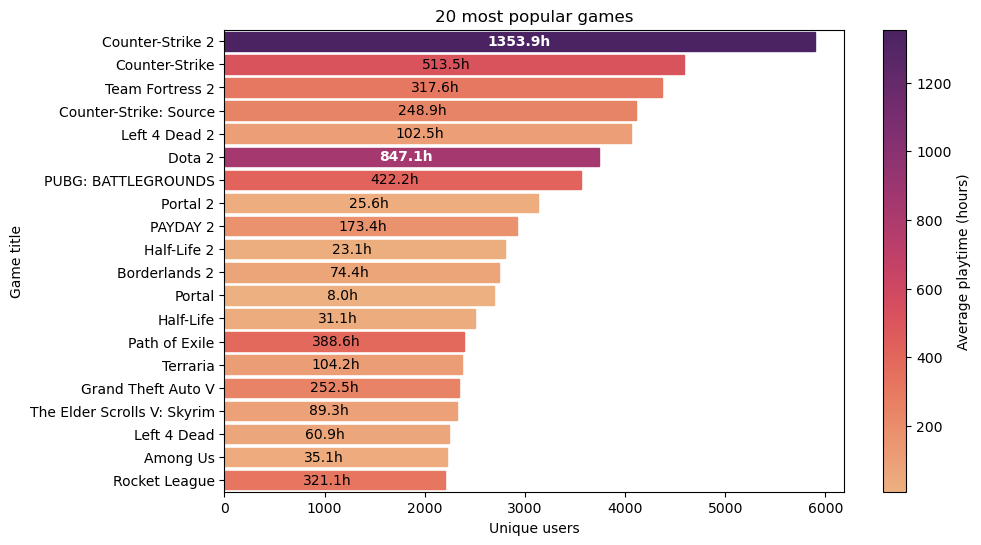

In [80]:
df = pd.DataFrame(data)

# create bar plot with seaborn
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x="total_users", y="game", data=df, ax=ax, orient='h')

# Normalize the values of avg_time for the color gradient
norm = plt.Normalize(df["avg_time"].min(), df["avg_time"].max())

# Create a Seaborn color palette
palette = sns.color_palette("flare", as_cmap=True)

# Map the colors from the Seaborn palette to the bars
colors = palette(norm(df["avg_time"]))

# set the color of each bar
for i, bar in enumerate(bars.patches):
    bar.set_color(colors[i])
    # if i == 0 or 5, set text color to white and font weight to bold
    if i == 0 or i == 5:
        ax.text(bar.get_width() // 2 - 320, bar.get_y() + bar.get_height() / 2, f'{data["avg_time"][i]:.1f}h', va='center', color='white', fontweight='bold')
    else:
        ax.text(bar.get_width() // 2 - 320, bar.get_y() + bar.get_height() / 2, f'{data["avg_time"][i]:.1f}h', va='center')

# Add a color bar (legend) for the avg_time
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Average playtime (hours)')

ax.set_xlabel("Unique users")
ax.set_ylabel("Game title")
ax.set_title("20 most popular games")

plt.savefig("top20games.png", bbox_inches='tight')

plt.show()

In [81]:
# sort game_time by avg_time
game_time.sort_values("avg_time", ascending=False, inplace=True)
# get rid of games with less than 50 users
game_time = game_time[game_time["total_users"] >= 50]
game_time.head(20)

,game_steam_id,total_time,total_users,avg_time,game_name
0,730,7981049,5895,1353.87,Counter-Strike 2
873,627690,423323,330,1282.80,Idle Champions of the Forgotten Realms
5966,466170,73978,64,1155.91,Idling to Rule the Gods
2511,1147690,156156,153,1020.63,NGU IDLE
3818,400040,90350,105,860.48,ShareX
5,570,3166377,3738,847.08,Dota 2
6139,1013320,51545,62,831.37,Firestone: Online Idle RPG
4396,1891700,74922,91,823.32,Tap Ninja
688,39210,272420,399,682.76,FINAL FANTASY XIV Online
1211,1454400,175225,258,679.17,Cookie Clicker


In [82]:
data = {
    'game': [],
    'total_time': [],
    'avg_time': [],
    'total_users': []
}
for row in game_time.head(20).iterrows():
    data["game"].append(row[1]["game_name"])
    data["total_time"].append(row[1]["total_time"])
    data["avg_time"].append(row[1]["avg_time"])
    data["total_users"].append(row[1]["total_users"])

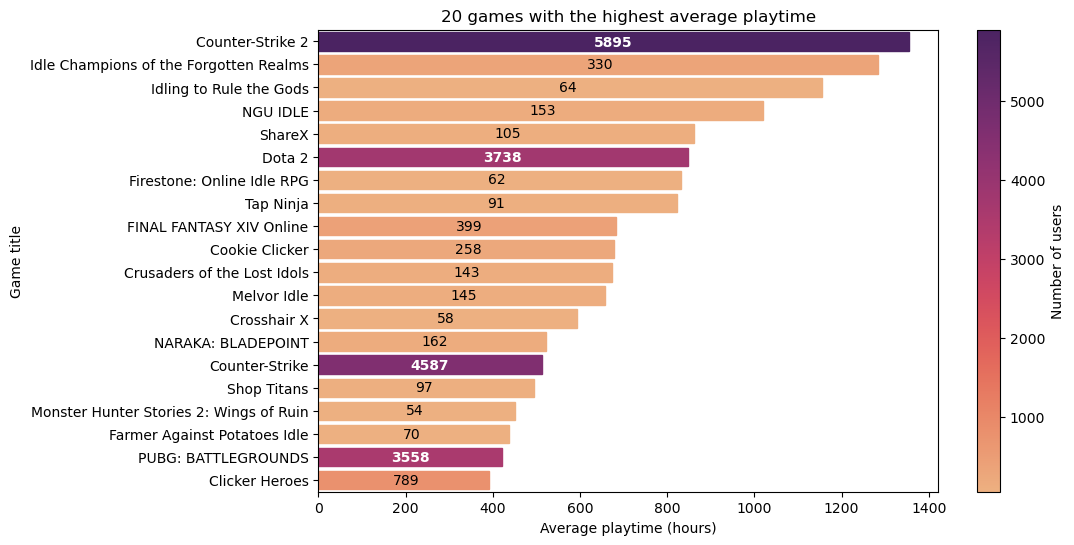

In [83]:
df = pd.DataFrame(data)

# create bar plot with seaborn
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x="avg_time", y="game", data=df, ax=ax, orient='h')

# Normalize the values of avg_time for the color gradient
norm = plt.Normalize(df["total_users"].min(), df["total_users"].max())

# Create a Seaborn color palette
palette = sns.color_palette("flare", as_cmap=True)

# Map the colors from the Seaborn palette to the bars
colors = palette(norm(df["total_users"]))

# set the color of each bar
for i, bar in enumerate(bars.patches):
    bar.set_color(colors[i])
    if i == 0 or i == 14 or i == 5 or i == 18:
        ax.text(bar.get_width() // 2 - 45, bar.get_y() + bar.get_height() / 2 + 0.03, f'{data["total_users"][i]}', va='center', color='white', fontweight='bold')
    else:
        ax.text(bar.get_width() // 2 - 25, bar.get_y() + bar.get_height() / 2, f'{data["total_users"][i]}', va='center')

# Add a color bar (legend) for the avg_time
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Number of users')

ax.set_xlabel("Average playtime (hours)")
ax.set_ylabel("Game title")
ax.set_title("20 games with the highest average playtime")

plt.savefig("top20avg.png", bbox_inches='tight')

plt.show()

In [86]:
game_tags = "data/game_data_with_tags.csv"

game_tags_data = pd.read_csv(game_tags)
game_tags_data.head()

,game_id,game_steam_id,game_name,tag_0,tag_1,tag_2,tag_3,tag_4,rating
0,1,4000,Garry's Mod,Sandbox,Moddable,Multiplayer,Physics,Building,96.0
1,2,400,Portal,Puzzle,Puzzle Platformer,First-Person,3D Platformer,Singleplayer,98.0
2,3,20900,The Witcher: Enhanced Edition,RPG,Fantasy,Story Rich,Mature,Singleplayer,89.0
3,4,22000,World of Goo,Puzzle,Indie,Physics,Singleplayer,Great Soundtrack,94.0
4,5,17410,Mirror's Edge,Action-Adventure,Parkour,First-Person,Exploration,3D Platformer,87.0


In [ ]:
data = {
    "game": [],
    "rating": [],
    "tags": {}
}

for game in game_tags_data.iterrows():
    # check if rating is nan
    if not np.isnan(game[1].rating):
        data["game"].append(game[1].game_name)
        data["rating"].append(int(game[1].rating))
    for i in range(1, 5):
        tag = game[1][f"tag_{i}"]
        # check if tag is nan
        if pd.isnull(tag):
            break
        if tag not in data["tags"]:
            data["tags"][tag] = 1
        else:
            data["tags"][tag] += 1

data

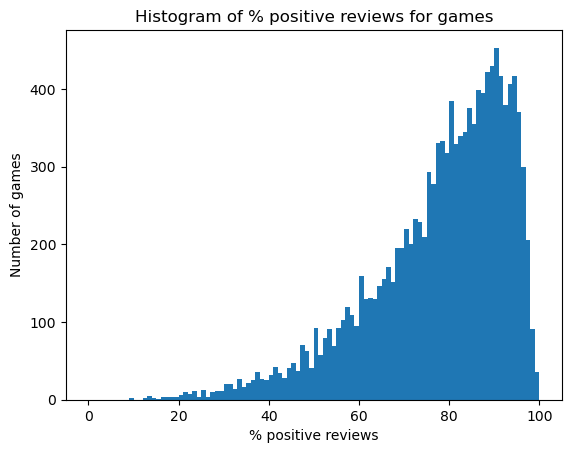

In [88]:
# make a histogram of rating % for games
plt.hist(data["rating"], bins=np.arange(0, 101, 1))
plt.xlabel("% positive reviews")
plt.ylabel("Number of games")
plt.title("Histogram of % positive reviews for games")

plt.savefig("rating_hist.png", bbox_inches='tight')

plt.show()

In [89]:
# take 20 most popular tags
tags = sorted(data["tags"].items(), key=lambda x: x[1], reverse=True)
tags = tags[:20]
new_tags = []
for i in range(len(tags)-1, -1, -1):
    new_tags.append(tags[i])
new_tags

[('Open World', 477),
 ('Story Rich', 505),
 ('Female Protagonist', 534),
 ('Anime', 535),
 ('Shooter', 539),
 ('FPS', 544),
 ('Point & Click', 551),
 ('2D', 565),
 ('Pixel Graphics', 660),
 ('Platformer', 763),
 ('Singleplayer', 1098),
 ('RPG', 1145),
 ('Puzzle', 1192),
 ('Simulation', 1259),
 ('Strategy', 1294),
 ('Multiplayer', 1324),
 ('Casual', 2074),
 ('Adventure', 2431),
 ('Action', 2777),
 ('Indie', 4171)]

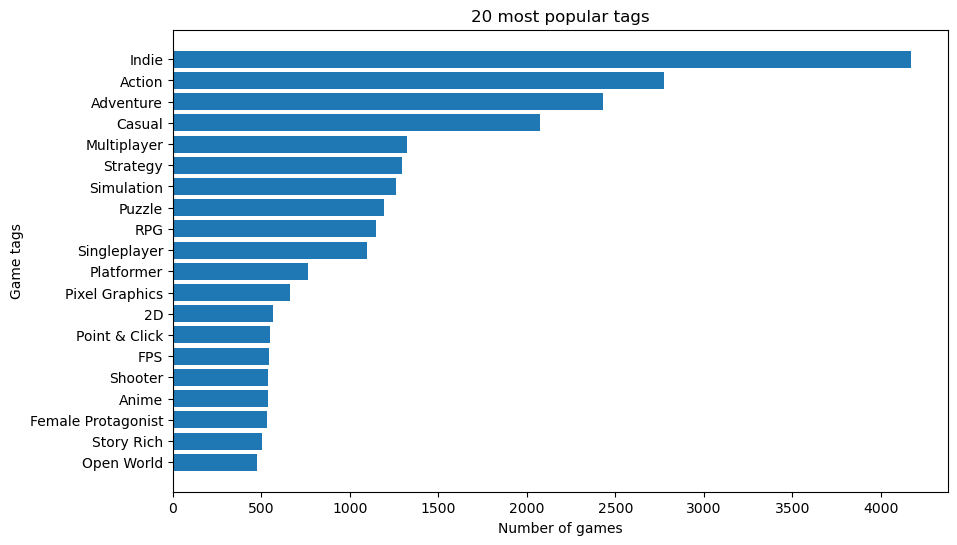

In [91]:
# make a bar plot of the 20 most popular tags
# tags on the y axis, values on the x
plt.figure(figsize=(10, 6))

plt.barh([tag[0] for tag in new_tags], [tag[1] for tag in new_tags])
plt.xlabel("Number of games")
plt.ylabel("Game tags")
plt.title("20 most popular tags")

plt.savefig("tags_bar.png", bbox_inches='tight')

plt.show()
